**Суркова Татьяна**

## Домашнее задание 3

Задание 1

Для каждого покупателя получите таблицу со столбцами:

preferred_payment - самый частый метод оплаты (при ничьей зафиксируйте правило, например lexicographically первый);

total_spent - сумма всех трат;

addons_spent - сумма на дополнительные услуги и аксессуары;

orders_count - число заказов.
 
 Отсортируйте по total_spent по убыванию и выведите топ-10.

Пограничные случаи:

• Покупатель с одним заказом - orders_count = 1, preferred_payment = единственный метод.
 
• Два метода оплаты с одинаковой частотой - выберите один по зафиксированному правилу (укажите его в комментарии к коду).

• Покупатель без доп. услуг/аксессуаров - addons_spent = 0.

• Пропуски в сумме или методе оплаты - обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.



In [2]:
import pandas as pd

df = pd.read_csv('./data/Electronic_sales_Sep2023-Sep2024.csv', sep =',')

df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [3]:
# обработка пропусков (по условию в сумме или методах оплаты)

df['Payment Method'] = df['Payment Method'].fillna('Unknown')
df['Total Price'] = df['Total Price'].fillna(0)
df['Add-on Total'] = df['Add-on Total'].fillna(0)

In [ ]:
preferred_payment = (
    df.groupby(['Customer ID', 'Payment Method'])
    .size()
    .reset_index(name='count')
    .sort_values(['Customer ID', 'count', 'Payment Method'], ascending=[True, False, True])
    .drop_duplicates('Customer ID') # оставить после сортировки 1-ый метод оплаты (выведет оплату с максимальным count, либо оплату по алфавиту)
    .rename(columns={'Payment Method': 'preferred_payment'})
)

df = (
    df.groupby('Customer ID')
    .agg({'Total Price': 'sum', 
          'Add-on Total': 'sum', 
          'Order Status': 'size'})
    .rename(columns={'Total Price': 'total_spent', 'Add-on Total': 'addons_spent', 'Order Status': 'orders_count'})
)

result = df.merge(preferred_payment, on='Customer ID').rename(columns={'Customer ID': 'customer_id'})

print(result[['customer_id', 'preferred_payment', 'total_spent', 'addons_spent', 'orders_count']].sort_values('total_spent', ascending=False).head(10))

       customer_id preferred_payment  total_spent  addons_spent  orders_count
9728         16357     Bank Transfer     34563.70           491             7
10049        16863            PayPal     33035.92           484             5
8060         13813       Credit Card     31830.16           267             5
6475         11476            PayPal     31077.61           299             5
7028         12276     Bank Transfer     30961.18           328             6
7935         13635       Credit Card     30260.36           478             5
7352         12749       Credit Card     29394.56           617             5
9087         15399            PayPal     29084.88           305             3
7054         12319     Bank Transfer     27352.32           226             3
12133        19996     Bank Transfer     27296.78           430             6


Задание 2

Постройте пайплайн на Pandas (без циклов по строкам):
 
 1. Очистка: типы дат, пропуски, аномалии (отрицательные суммы / нулевые цены) - кратко опишите, что отфильтровали.
 2. Метрики:
 
    • доход по методу доставки;
    
    • доход по типу продукта;
    
    • доход по доп. услугам: по месяцам и по кварталам;
    
    • cohort-анализ: когорта = месяц первого заказа покупателя; для каждой когорты - выручка и число покупателей в следующие 0, 1, 2, 3 месяца.
 3. Визуализация (минимум 3 графика): bar (доставка / тип продукта), line (доп. услуги по месяцам), heatmap когортной матрицы выручки.
 4. Выводы: несколько предложений по графикам. (?необязательно)
 
 Дополнительно: оформите шаги 1–2 как функции clean(df) → df и build_metrics(df) → dict[str, DataFrame].

Пограничные случаи:

Заказы с отрицательной или нулевой ценой - не должны попадать в доход после clean.

Покупатель с одним заказом - в когортной матрице заполнен только месяц 0.

Месяц без доп. услуг - в addons_by_month строка с 0 или отсутствие месяца (выберите и зафиксируйте поведение).

Пустой датасет после очистки → функции не падают, возвращают пустые таблицы.

In [5]:
df = pd.read_csv('./data/Electronic_sales_Sep2023-Sep2024.csv', sep =',')

df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [6]:
df.isna().sum()  # смотрим, где есть na для последующей очистки

Customer ID             0
Age                     0
Gender                  1
Loyalty Member          0
Product Type            0
SKU                     0
Rating                  0
Order Status            0
Payment Method          0
Total Price             0
Unit Price              0
Quantity                0
Purchase Date           0
Shipping Type           0
Add-ons Purchased    4868
Add-on Total            0
dtype: int64

In [7]:
df.dtypes

Customer ID            int64
Age                    int64
Gender                   str
Loyalty Member           str
Product Type             str
SKU                      str
Rating                 int64
Order Status             str
Payment Method           str
Total Price          float64
Unit Price           float64
Quantity               int64
Purchase Date            str
Shipping Type            str
Add-ons Purchased        str
Add-on Total         float64
dtype: object

In [8]:
df.describe()

,Customer ID,Age,Rating,Total Price,Unit Price,Quantity,Add-on Total
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10483.526550,48.994100,3.093950,3180.133418,578.631867,5.485550,62.244848
std,5631.732525,18.038745,1.223764,2544.978675,312.274076,2.870854,58.058431
min,1000.000000,18.000000,1.000000,20.750000,20.750000,1.000000,0.000000
25%,5478.000000,33.000000,2.000000,1139.680000,361.180000,3.000000,7.615000
50%,10499.500000,49.000000,3.000000,2534.490000,463.960000,5.000000,51.700000
75%,15504.000000,65.000000,4.000000,4639.600000,791.190000,8.000000,93.842500
max,19998.000000,80.000000,5.000000,11396.800000,1139.680000,10.000000,292.770000


In [ ]:
def clean(df) -> pd.Dataframe:

    # приводим к типу datetime
    df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')

    # обработка пропусков по данным из анализа выше df.isna().sum() 
    df['Gender'] = df['Gender'].fillna('Unknown')
    df['Add-on Total'] = df['Add-on Total'].fillna(0) # 0 в случае отсутствия доп услуг
    df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('Unknown')

    # приводим к типу int
    df['Add-on Total'] = df['Add-on Total'].astype(int)

    # отфильтровываем аномалии:
    df = df[
        (df["Age"] > 0) &
        (df["Rating"].between(1, 5)) &
        (df["Unit Price"] > 0) &
        (df["Total Price"] > 0) &
        (df["Quantity"] > 0) &
        (df["Add-on Total"] >= 0)
    ]

    return df

In [10]:
clean(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        20000 non-null  int64         
 1   Age                20000 non-null  int64         
 2   Gender             20000 non-null  str           
 3   Loyalty Member     20000 non-null  str           
 4   Product Type       20000 non-null  str           
 5   SKU                20000 non-null  str           
 6   Rating             20000 non-null  int64         
 7   Order Status       20000 non-null  str           
 8   Payment Method     20000 non-null  str           
 9   Total Price        20000 non-null  float64       
 10  Unit Price         20000 non-null  float64       
 11  Quantity           20000 non-null  int64         
 12  Purchase Date      20000 non-null  datetime64[us]
 13  Shipping Type      20000 non-null  str           
 14  Add-ons Purchased

In [ ]:
def build_metrics(df) -> dict[str, pd.DataFrame]:

    # обработка пустого df
    if df.empty: 
        return { "revenue_by_shipping": pd.DataFrame( columns=["shipping_method", "revenue"] ), 
                "revenue_by_product_type": pd.DataFrame( columns=["product_type", "revenue"] ), 
                "addon_by_month": pd.DataFrame( columns=["month", "addons_revenue"] ), 
                "addon_by_quarter": pd.DataFrame( columns=["quarter", "addons_revenue"] ), 
                "cohort_revenue": pd.DataFrame(), "cohort_customers_cnt": pd.DataFrame(), }

    # доход по методу доставки
    revenue_by_shipping = df.groupby(['Shipping Type'])['Total Price'].sum().reset_index(name='revenue').rename(columns={'Shipping Type': 'shipping_method'})

    #доход по типу продукта
    revenue_by_product_type = df.groupby(['Product Type'])['Total Price'].sum().reset_index(name='revenue').rename(columns={'Product Type': 'product_type'})

    #доход по месяцам и кварталам (исходя из условия, без разбивки по годам)
    df['month'] = df['Purchase Date'].dt.to_period('M')
    df['quarter'] = df['Purchase Date'].dt.quarter
    addon_by_month = df.groupby(['month'])['Add-on Total'].sum().reset_index(name='addons_revenue')
    addon_by_quarter = df.groupby(['quarter'])['Add-on Total'].sum().reset_index(name='addons_revenue')

    # когортный анализ
    # добавим инфо о первом месяце покупки для каждого клиента
    df['First Month'] = df.groupby("Customer ID")["Purchase Date"].transform("min").dt.to_period('M')
    # определим порядковый месяц жизни клиента через ранг
    df["Month Number"] = (df.groupby("Customer ID")["month"].rank(method="dense").astype(int) - 1)

    # когорта по выручке
    cohort_revenue = pd.DataFrame()
    for x in range(4):
        cohort_revenue[x] = (
            df[df["Month Number"] == x]
            .groupby("First Month")["Total Price"]
            .sum()
        )

    # когорта по кол-ву покупателей
    cohort_customers_cnt = pd.DataFrame()
    for x in range(4):
        cohort_customers_cnt[x] = (
            df[df["Month Number"] == x]
            .groupby("First Month")["Customer ID"]
            .count()
        )

    # словарь метрика -> DataFrame
    return {
        "revenue_by_shipping": revenue_by_shipping,
        "revenue_by_product_type": revenue_by_product_type,
        "addon_by_month": addon_by_month,
        "addon_by_quarter": addon_by_quarter,
        "cohort_revenue": cohort_revenue,
        "cohort_customers_cnt": cohort_customers_cnt,
    }

In [12]:
metrics = build_metrics(df)
metrics

{'revenue_by_shipping':   shipping_method      revenue
 0       Expedited  12437526.21
 1         Express   8685215.62
 2       Overnight   8704828.17
 3        Same Day  12432024.82
 4        Standard  21343073.55,
 'revenue_by_product_type':   product_type      revenue
 0   Headphones   4041400.24
 1       Laptop  12296239.97
 2   Smartphone  21516754.69
 3   Smartwatch  14036273.06
 4       Tablet  11712000.41,
 'addon_by_month':       month  addons_revenue
 0   2023-09            7937
 1   2023-10           37490
 2   2023-11           34594
 3   2023-12           33180
 4   2024-01          135419
 5   2024-02          119444
 6   2024-03          124216
 7   2024-04          123281
 8   2024-05          131271
 9   2024-06          125962
 10  2024-07          131277
 11  2024-08          134368
 12  2024-09           98962,
 'addon_by_quarter':    quarter  addons_revenue
 0        1          379079
 1        2          380514
 2        3          372544
 3        4          1052

**Визуализация**

Визуализация (минимум 3 графика): bar (доставка / тип продукта), line (доп. услуги по месяцам), heatmap когортной матрицы выручки.

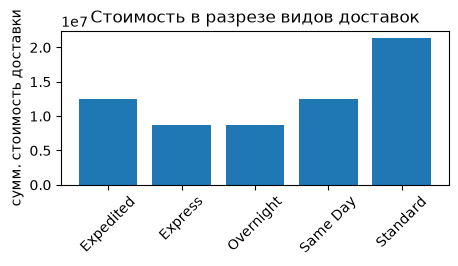

In [13]:
import matplotlib.pyplot as plt

# bar доставка
df_bar_prep = metrics['revenue_by_shipping']

plt.figure(figsize=(5, 2))

plt.bar(
    df_bar_prep['shipping_method'],
    df_bar_prep['revenue']
)

plt.xticks(rotation=45)
plt.title("Стоимость в разрезе видов доставок")
plt.ylabel("сумм. cтоимость доставки")

plt.show()

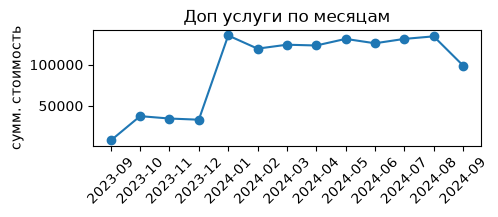

In [14]:
import matplotlib.pyplot as plt

# line доп услуги по месяцам
df_plot_prep = metrics['addon_by_month']

plt.figure(figsize=(5, 1.5))

plt.plot(
    df_plot_prep['month'].astype(str),
    df_plot_prep['addons_revenue'],
    marker='o'
)

plt.xticks(rotation=45)
plt.title("Доп услуги по месяцам")
plt.ylabel("сумм. cтоимость")

plt.show()

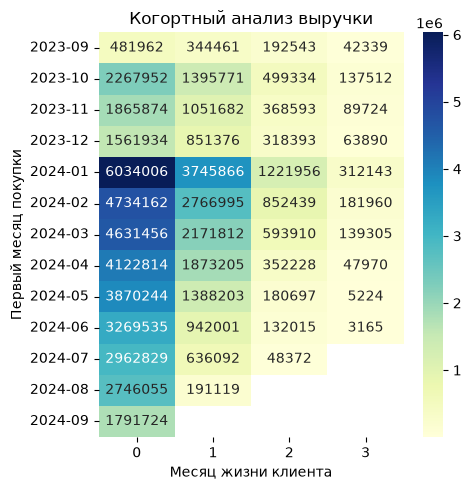

In [15]:
# heatmap
import seaborn as sns

df_heatmap_prep = metrics['cohort_revenue']

plt.figure(figsize=(5, 5))

sns.heatmap(
    df_heatmap_prep,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Когортный анализ выручки')
plt.xlabel('Месяц жизни клиента')
plt.ylabel('Первый месяц покупки')

plt.tight_layout()
plt.show()
